In [73]:
#Import necessary Python modules
import os, warnings, tempfile, pysam

import dms_variants.utils
import Bio.SeqIO

import numpy as np
import pandas as pd
import altair as alt

import alignparse.ccs
import alignparse.consensus
import alignparse.minimap2
import alignparse.targets
import alignparse.cs_tag
from alignparse.constants import CBPALETTE
from pathos.helpers import mp

from plotnine import *
from IPython.display import display

In [55]:
#Suppress warnings that clutter output
warnings.simplefilter("ignore")
alt.data_transformers.enable("default", max_rows=None)

DataTransformerRegistry.enable('default')

In [56]:
#Directory for output
current_dir = os.getcwd()
print(current_dir)

outdir = "./output_files/"
os.makedirs(outdir, exist_ok=True)

/public1/biousers/jiachenli/PacBio/KPC.barcode


In [57]:
#Color palette for plots
CBPALETTE = ("#999999", "#E69F00", "#56B4E9", "#009E73")

LOCUS       KPC-2_PacBio_amplicon                1181 bp ds-DNA     linear   SYN 27-JAN-2026
DEFINITION  PacBio amplicon for deep mutational scanning of K.p KPC-2.
ACCESSION   .
VERSION     .
KEYWORDS    .
SOURCE      Jiachen Li
  ORGANISM  .
COMMENT     PacBio amplicon for KPC-2 libraries.
FEATURES             Location/Qualifiers
     termini5        1..20
                     /label=termini5
     gene_flank5     21..40
                     /label=gene_flank5
     gene            41..922
                     /label=blaKPC-2
     gene_flank3     923..942
                     /label=gene_flank3
     terminator      982..1068
                     /label=rrnB T1 terminator
     barcode         1082..1101
                     /label=barcode
     termini3        1162..1181
                     /label=termini3
ORIGIN
        1 cgctacacct agctccacct tcaaacaagg aatatcgttg atgtcactgt atcgccgtct
       61 agttctgctg tcttgtctct catggccgct ggctggcttt tctgccaccg cgctgaccaa
      121 cctcgtcgcg gaac

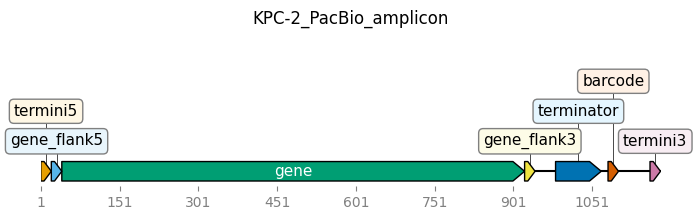

In [58]:
#Read the target amplicon
kpc2_targetfile = "./KPC-2_amplicon.gb"
with open(kpc2_targetfile) as f:
    print(f.read())

kpc2_parse_specs_file = "./KPC-2_feature_parse_specs.yaml"
with open(kpc2_parse_specs_file) as f:
    print(f.read())

target = alignparse.targets.Targets(
    seqsfile=kpc2_targetfile,
    feature_parse_specs=kpc2_parse_specs_file,
    allow_extra_features=True
)

fig = target.plot(
    ax_width=8,
    plots_indexing="genbank",
    ax_height=2,
    hspace=1.2,
)


In [59]:
#Call ccs reads in FASTQ file
raw_bam =  "m64284e_240816_165925.subreads.bam"
file_pfx = "kpc_pacbio"
#os.system("ccs --min-passes %d --min-length %d --max-length %d -j %d --min-rq 0.99 --report-file %s %s %s" % (3, 900, 2000, 32, file_pfx + "_ccs_report.txt", raw_bam, file_pfx + "_ccs.bam"))
#os.system("/usr/local/bin/samtools bam2fq -T np,rq %s | gzip > %s" % (file_pfx + "_ccs.bam", file_pfx + "_ccs.fastq.gz"))

In [60]:
#Create a ccs_summaries object for these CCSs
pacbio_runs = pd.DataFrame(
    {
        "name": [file_pfx],
        "report":["%s_ccs_report.txt" % (file_pfx)],
        "fastq": ["%s_ccs.fastq.gz" % (file_pfx)],
    }
)

ccs_summaries = alignparse.ccs.Summaries(pacbio_runs, ncpus=16)

In [74]:
#Draw the ZMW stats
display(ccs_summaries.zmw_stats())

ccs_summaries_zmw_chart = (
    alt.Chart(ccs_summaries.zmw_stats())
    .encode(
        x="number:Q",
        y=alt.Y(
            "name:N",
            axis=alt.Axis(title=None),
        ),
        color="status:N",
        tooltip=ccs_summaries.zmw_stats().columns.tolist(),
    )
    .mark_bar()
    .properties(width=400, height=40)
    .resolve_scale(x="independent", y="independent")
)

ccs_summaries_zmw_chart

,name,status,number,fraction
0,kpc_pacbio,Success -- CCS generated,3652155,0.514064
1,kpc_pacbio,Failed -- Lacking full passes,2761594,0.388712
2,kpc_pacbio,Failed -- CCS below minimum RQ,332039,0.046737
3,kpc_pacbio,Failed -- Other reason,95791,0.013483
4,kpc_pacbio,Failed -- Draft below --min-length,95187,0.013398
5,kpc_pacbio,Failed -- Draft generation error,94929,0.013362
6,kpc_pacbio,Failed -- Below SNR threshold,72784,0.010245


alt.Chart(...)

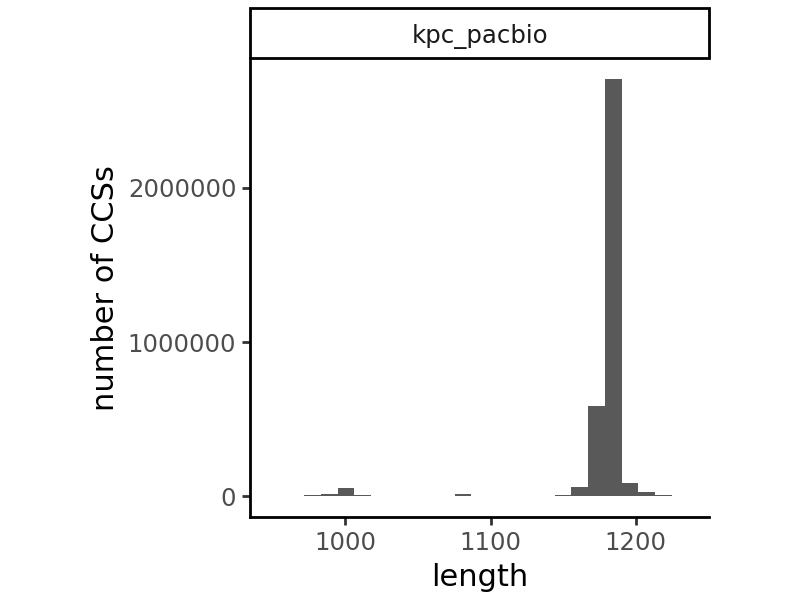

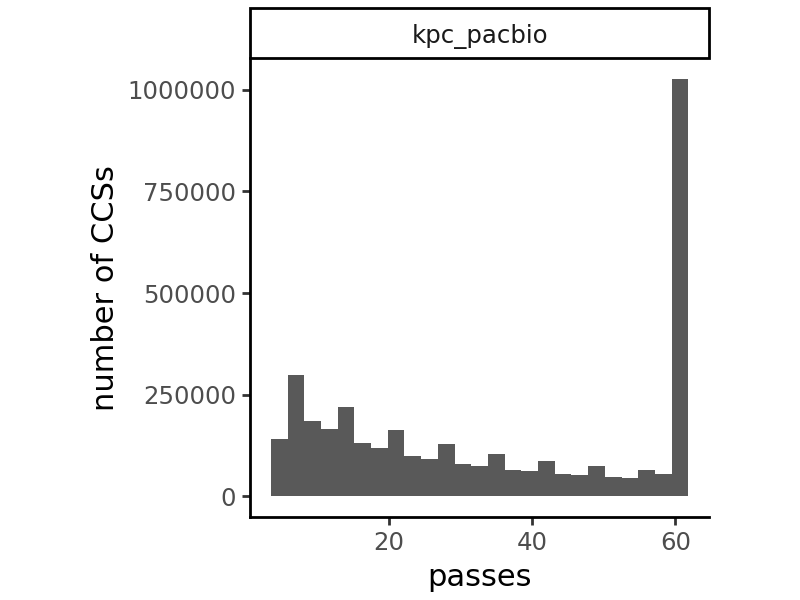

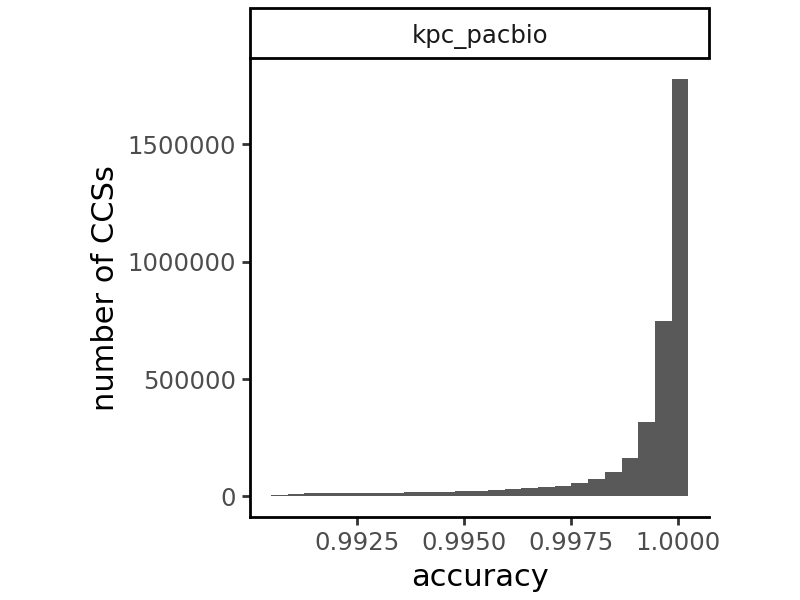

In [62]:
#Statistics on the CCSs (length, number of subread passes, quality)
nccs_figures = []
for stat in ["length", "passes", "accuracy"]:
    if ccs_summaries.has_stat(stat):
        p = ccs_summaries.plot_ccs_stats(stat)
        p = (p 
             + theme_classic() 
             + theme(aspect_ratio=1, panel_grid_major_x=element_blank(), figure_size=(4, 3))
        )
        nccs_figures.append(p)
    else:
        print("No information available on CCS %s" % (stat))
        
for out in nccs_figures:
    display(out)

In [63]:
#Align and parse CCSs
mapper = alignparse.minimap2.Mapper(alignparse.minimap2.OPTIONS_CODON_DMS)

print(
    "Using `minimap2` %s with these options:\n" % (mapper.version)
    + " ".join(mapper.options)
)

align_and_parse_outdir = os.path.join(outdir, "kpc2_align_and_parse")

readstats, aligned, filtered = target.align_and_parse(
    df=pacbio_runs,
    mapper=mapper,
    outdir=align_and_parse_outdir,
    name_col="name",
    queryfile_col="fastq",
    overwrite=True,  # overwrite any existing output
    ncpus=16,  # use all available CPUs
)

print("Contents of %s:\n" % (align_and_parse_outdir) + "-" * 48)
for d, _, fs in sorted(os.walk(align_and_parse_outdir)):
    for f in sorted(fs):
        print("  " + os.path.relpath(os.path.join(d, f), align_and_parse_outdir))

Using `minimap2` 2.30-r1287 with these options:
-A2 -B4 -O12 -E2 --end-bonus=13 --secondary=no --cs
Contents of ./output_files/kpc2_align_and_parse:
------------------------------------------------
  KPC-2_PacBio_amplicon_aligned.csv
  KPC-2_PacBio_amplicon_aligned_barcode_rcsequence.csv
  KPC-2_PacBio_amplicon_filtered.csv
  KPC-2_PacBio_barcode_variant_link.csv
  kpc_pacbio/KPC-2_PacBio_amplicon_aligned.csv
  kpc_pacbio/KPC-2_PacBio_amplicon_filtered.csv
  kpc_pacbio/alignments.sam


In [1]:
#Summary statistics
display(readstats)

readstats_chart = (
    alt.Chart(readstats)
    .encode(
        x="count:Q",
        y=alt.Y(
            "category:N",
            axis=alt.Axis(title=None),
        ),
        tooltip=readstats.columns.tolist(),
    )
    .mark_bar()
    .properties(width=400, height=100)
    .resolve_scale(x="independent", y="independent")
)

readstats_chart

NameError: name 'readstats' is not defined

In [65]:
#Statistics of aligned and filtered information
filtered_df = filtered[target.target_names[0]]

filtered_reasons = pd.concat(
    [
        filtered_df.groupby(["name", "filter_reason"], as_index=False).aggregate(
            count=pd.NamedAgg("query_name", "count")
        ),
        readstats.query('category.str.startswith("aligned")', engine="python")
        .groupby("name", as_index=False)
        .aggregate({"count": "sum"})
        .assign(filter_reason="aligned"),
    ]
).assign(
    total_counts=lambda x: x.groupby("name")["count"].transform("sum"),
    frac_counts=lambda x: x["count"] / x["total_counts"],
)

print("CCSs mapped information for %s" % (target.target_names[0]))
display(filtered_reasons)

filtered_chart = (
    alt.Chart(filtered_reasons)
    .encode(
        x="count:Q",
        y=alt.Y(
            "filter_reason:N",
            axis=alt.Axis(title=None),
        ),
        color="is_aligned:N",
        tooltip=filtered_reasons.columns.tolist(),
    )
    .mark_bar()
    .properties(width=400, height=100)
    .resolve_scale(x="independent", y="independent")
    .transform_filter(alt.datum.frac_counts > 0.01)
    .transform_calculate(is_aligned=alt.datum.filter_reason == "aligned")
)

filtered_chart

CCSs mapped information for KPC-2_PacBio_amplicon


,name,filter_reason,count,total_counts,frac_counts
0,kpc_pacbio,barcode clip3,63833,3650568,0.017486
1,kpc_pacbio,barcode mutation_nt_count,720668,3650568,0.197413
2,kpc_pacbio,gene clip3,791,3650568,0.000217
3,kpc_pacbio,gene mutation_nt_count,60020,3650568,0.016441
4,kpc_pacbio,gene_flank3 clip3,839,3650568,0.000230
5,kpc_pacbio,gene_flank3 mutation_nt_count,10321,3650568,0.002827
6,kpc_pacbio,gene_flank5 mutation_nt_count,9047,3650568,0.002478
7,kpc_pacbio,query_clip3,16851,3650568,0.004616
8,kpc_pacbio,query_clip5,31096,3650568,0.008518
9,kpc_pacbio,termini3 clip3,68669,3650568,0.018810


alt.Chart(...)

In [70]:
#Detailed information of aligned CCSs
assert len(aligned) == 1, "not just one target"

aligned_df = aligned[target.target_names[0]].assign(
    barcode=lambda x: x["barcode_sequence"].map(dms_variants.utils.reverse_complement)
)[
    [
        "name",
        "query_name",
        "barcode",
        "barcode_sequence",
        "gene_mutations",
        "barcode_accuracy",
        "gene_accuracy",
    ]
]

display(aligned_df)

aligned_df.to_csv(os.path.join(outdir, "kpc2_align_and_parse/") + "KPC-2_PacBio_ccs_aligned.csv", index=False)

,name,query_name,barcode,barcode_sequence,gene_mutations,barcode_accuracy,gene_accuracy
0,kpc_pacbio,m64284e_240816_165925/9/ccs,GGGATTAATTCTTTGGTTAA,TTAACCAAAGAATTAATCCC,,1.000000,1.000000
1,kpc_pacbio,m64284e_240816_165925/11/ccs,GGGACGACATTGGCGTCCTT,AAGGACGCCAATGTCGTCCC,del546to546 G548A del574to574 C587G T588G ins607C,0.999852,0.997832
2,kpc_pacbio,m64284e_240816_165925/13/ccs,CGTCTCGGTCGGTCACTTCG,CGAAGTGACCGACCGAGACG,,0.974211,0.999979
3,kpc_pacbio,m64284e_240816_165925/20/ccs,GGGTAAGCTGTCGTCATCTG,CAGATGACGACAGCTTACCC,del547to547 A687C,0.999998,0.999989
4,kpc_pacbio,m64284e_240816_165925/22/ccs,ATCGCGTACAATTGTATGTT,AACATACAATTGTACGCGAT,A287G C288G,1.000000,1.000000
...,...,...,...,...,...,...,...
2581452,kpc_pacbio,m64284e_240816_165925/180554574/ccs,CAGCAGTTCCGGGTGGGGAA,TTCCCCACCCGGAACTGCTG,ins470C ins548A T625A G683A,0.960164,0.998864
2581453,kpc_pacbio,m64284e_240816_165925/180554576/ccs,ATTAACTACTTTCTAAGATT,AATCTTAGAAAGTAGTTAAT,C522T,1.000000,0.999943
2581454,kpc_pacbio,m64284e_240816_165925/180554583/ccs,TGGTCTATTGGCTCGGTTTG,CAAACCGAGCCAATAGACCA,ins36TC ins103A ins314CA ins396CG ins582A ins6...,1.000000,0.998906
2581455,kpc_pacbio,m64284e_240816_165925/180554584/ccs,TAGTAAATGTCATGGTAACT,AGTTACCATGACATTTACTA,T10C T12A T26G,1.000000,0.999943
